In [4]:
import os
import numpy as np
import librosa
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import Wav2Vec2Processor
from transformers import Wav2Vec2Model

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cdist

In [6]:
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model.eval()

print("Model Loaded Successfully!")

Loading weights: 100%|█████████████████████| 210/210 [00:00<00:00, 7211.55it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully!


In [7]:
ravdess_path = "/Users/ranjittn/Downloads/Ravdess"

audio_files = []

for root, dirs, files in os.walk(ravdess_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

audio_files = sorted(audio_files)[:10]

print("Selected Files:", len(audio_files))

Selected Files: 10


In [12]:
embeddings = []

for file in audio_files:

    print("Processing:", os.path.basename(file))

    audio, sr = librosa.load(file, sr=16000)

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)

    embeddings.append(embedding.squeeze().numpy())

embeddings = np.array(embeddings)

print("\nEmbedding Shape:", embeddings.shape)

Processing: 03-01-01-01-01-01-01.wav
Processing: 03-01-01-01-01-02-01.wav
Processing: 03-01-01-01-02-01-01.wav
Processing: 03-01-01-01-02-02-01.wav
Processing: 03-01-02-01-01-01-01.wav
Processing: 03-01-02-01-01-02-01.wav
Processing: 03-01-02-01-02-01-01.wav
Processing: 03-01-02-01-02-02-01.wav
Processing: 03-01-02-02-01-01-01.wav
Processing: 03-01-02-02-01-02-01.wav

Embedding Shape: (10, 768)


In [13]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[1.0000002  0.99187523 0.9789741  0.9769369  0.9882364  0.9878474
  0.9753816  0.9749902  0.98921025 0.9831663 ]
 [0.99187523 0.9999998  0.9766428  0.97015524 0.990346   0.9833079
  0.97393966 0.97223765 0.98350924 0.98215723]
 [0.9789741  0.9766428  0.9999999  0.9883807  0.9807793  0.97783494
  0.9920072  0.9931172  0.9768561  0.9753604 ]
 [0.9769369  0.97015524 0.9883807  0.9999999  0.9729108  0.97480565
  0.98469025 0.98640585 0.9740867  0.97083366]
 [0.9882364  0.990346   0.9807793  0.9729108  0.9999998  0.99218214
  0.9823507  0.9781567  0.99028826 0.99236584]
 [0.9878474  0.9833079  0.97783494 0.97480565 0.99218214 1.0000001
  0.97869503 0.97801584 0.99159616 0.9939114 ]
 [0.9753816  0.97393966 0.9920072  0.98469025 0.9823507  0.97869503
  1.0000001  0.99529266 0.9803648  0.9807608 ]
 [0.9749902  0.97223765 0.9931172  0.98640585 0.9781567  0.97801584
  0.99529266 0.99999994 0.97789246 0.9780372 ]
 [0.98921025 0.98350924 0.9768561  0.9740867  0.99028826 0.99159616
  0.9803648  0.

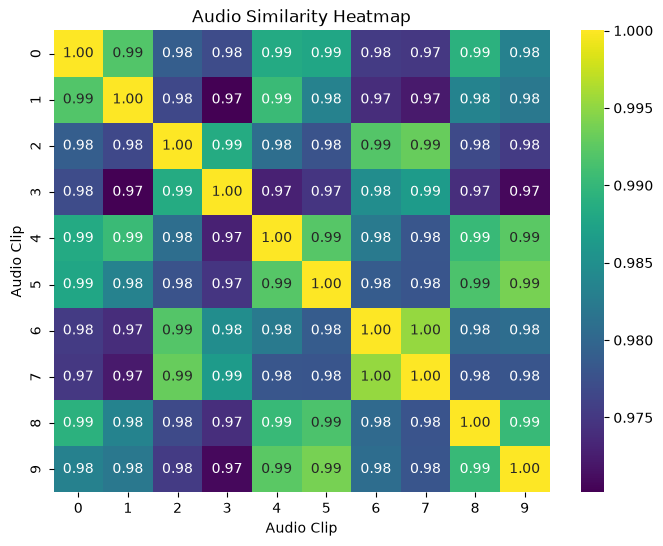

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Audio Similarity Heatmap")
plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.show()

In [15]:
distance_matrix = cdist(
    embeddings,
    embeddings,
    metric="euclidean"
)

print(distance_matrix)

[[0.         0.86169246 1.62493857 1.47044221 1.27028125 1.2170512
  1.90366361 1.81956519 1.36828921 1.68845164]
 [0.86169246 0.         1.66418665 1.67110678 1.13971226 1.35793255
  1.90236571 1.86192334 1.51962893 1.66946773]
 [1.62493857 1.66418665 0.         1.21385499 1.44916449 1.55333978
  1.00115517 0.88957496 1.61647585 1.70849262]
 [1.47044221 1.67110678 1.21385499 0.         1.71957818 1.61992206
  1.52234939 1.3679031  1.77428776 1.95285691]
 [1.27028125 1.13971226 1.44916449 1.71957818 0.         0.91927533
  1.4610065  1.57168207 1.0588918  1.00473388]
 [1.2170512  1.35793255 1.55333978 1.61992206 0.91927533 0.
  1.61646519 1.58472398 1.01290841 0.96415784]
 [1.90366361 1.90236571 1.00115517 1.52234939 1.4610065  1.61646519
  0.         0.75708277 1.52110975 1.51434891]
 [1.81956519 1.86192334 0.88957496 1.3679031  1.57168207 1.58472398
  0.75708277 0.         1.58893788 1.61028664]
 [1.36828921 1.51962893 1.61647585 1.77428776 1.0588918  1.01290841
  1.52110975 1.588937

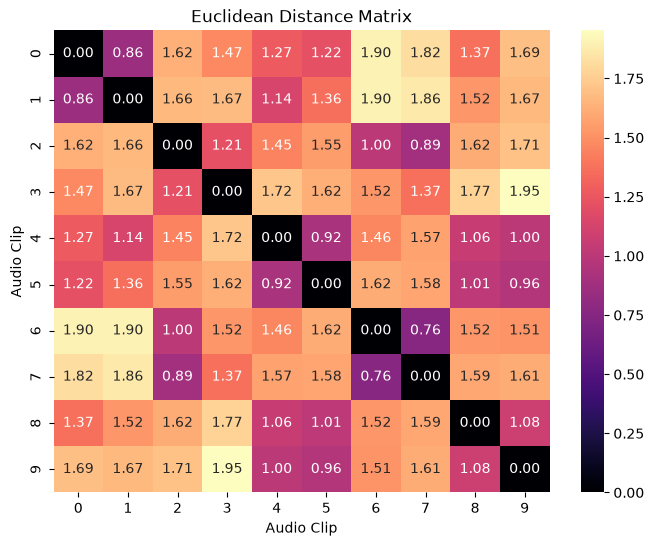

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_matrix,
    annot=True,
    cmap="magma",
    fmt=".2f"
)

plt.title("Euclidean Distance Matrix")
plt.xlabel("Audio Clip")
plt.ylabel("Audio Clip")

plt.show()

In [17]:
for i, file in enumerate(audio_files):
    print(f"{i+1}. {os.path.basename(file)}")

1. 03-01-01-01-01-01-01.wav
2. 03-01-01-01-01-02-01.wav
3. 03-01-01-01-02-01-01.wav
4. 03-01-01-01-02-02-01.wav
5. 03-01-02-01-01-01-01.wav
6. 03-01-02-01-01-02-01.wav
7. 03-01-02-01-02-01-01.wav
8. 03-01-02-01-02-02-01.wav
9. 03-01-02-02-01-01-01.wav
10. 03-01-02-02-01-02-01.wav


## Observations

- The pretrained Wav2Vec2 model successfully extracted 768-dimensional embeddings from the selected RAVDESS audio clips.
- Cosine similarity values close to 1 indicate highly similar speech characteristics, while lower values represent dissimilar audio samples.
- The diagonal elements of the similarity matrix are equal to 1 since each audio clip is perfectly similar to itself.
- The Euclidean distance matrix complements the similarity matrix by measuring the numerical distance between embedding vectors.
- Emotionally similar speech samples generally exhibit higher cosine similarity and lower Euclidean distance.
- This demonstrates that pretrained speech embeddings effectively capture acoustic characteristics useful for audio similarity tasks.